# InverseRG: 2D Compact U(1) Naive Pipeline

This notebook presents the full naive MCRG pipeline for 2D compact U(1) lattice gauge theory:

1. **HMC Sampling** -- generate fine-lattice configurations with Hybrid Monte Carlo
2. **Naive 2x2 Blocking** -- produce coarse configurations by summing consecutive link phases
3. **Independent Coarse HMC** -- generate coarse configurations directly from the Wilson action at $\beta_c = \beta_f / 4$
4. **Distribution Comparison** -- compare blocked-fine vs coarse-HMC ensembles at the distribution level

**Parameters:**
- Fine lattice: $L = 32$, $\beta_f = 4.0$, 1000 configurations
- Coarse lattice: $L = 16$, $\beta_c = 1.0$, 1000 configurations

**Caching:** Configurations are saved to `artifacts/cache/` after the first run. Subsequent runs load from cache instantly.

In [1]:
import pickle
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from inverserg.actions import LocalWilsonLoopAction
from inverserg.baselines import tree_level_coarse_beta
from inverserg.blocking import NaiveBlocker
from inverserg.hmc import HMCU1Sampler, HMCDiagnostics
from inverserg.lattice import plaquette_angles, regularize
from inverserg.measurements import (
    measurement_samples,
    plaquette_theory,
    topological_susceptibility_theory,
    autocorrelation_from_topo,
)
from inverserg.diagnostics import analyze_distribution_consistency

torch.manual_seed(42)

FINE_L = 32
FINE_BETA = 4.0
COARSE_L = FINE_L // 2
COARSE_BETA = tree_level_coarse_beta(FINE_BETA)
N_CONFIGS = 1000
HMC_STEPS = 10
HMC_STEP_SIZE = 0.1
BURN_IN = 200
THIN = 4

CACHE_DIR = Path("../artifacts/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Fine: L={FINE_L}, beta={FINE_BETA}")
print(f"Coarse: L={COARSE_L}, beta={COARSE_BETA}")
print(f"Configs per ensemble: {N_CONFIGS}")
print(f"Cache dir: {CACHE_DIR}")

Fine: L=32, beta=4.0
Coarse: L=16, beta=1.0
Configs per ensemble: 1000
Cache dir: ..\artifacts\cache


---
## Section A: HMC Sampling for 2D Compact U(1)

### The Fine-Lattice Theory

We simulate 2D compact U(1) lattice gauge theory on a periodic $L \times L$ square lattice. The degrees of freedom are link angles $\theta_\mu(x) \in [-\pi, \pi)$ for each link, where $\mu \in \{0, 1\}$ labels the direction (x or y).

The **Wilson plaquette action** is:
$$S[\theta] = -\beta \sum_{\text{plaquettes}} \cos(\theta_P)$$
where the plaquette angle $\theta_P$ is the oriented sum of link angles around each elementary square.

### HMC with Omelyan Integrator

We sample configurations using Hybrid Monte Carlo (HMC) with a second-order Omelyan integrator ($\lambda = 0.1932$). Each HMC trajectory:
1. Draws conjugate momenta $\pi$ from a Gaussian
2. Evolves $(\theta, \pi)$ via the Omelyan integrator for `n_steps` steps
3. Applies Metropolis accept/reject on the Hamiltonian $H = S(\theta) + \frac{1}{2}\pi^2$

### Exact Results

For 2D compact U(1) the mean plaquette has an exact analytic value:
$$\langle \cos(\theta_P) \rangle = \frac{I_1(\beta)}{I_0(\beta)}$$
where $I_n$ are modified Bessel functions.

In [2]:
fine_cache = CACHE_DIR / f"fine_L{FINE_L}_beta{FINE_BETA}_n{N_CONFIGS}.pkl"

if fine_cache.exists():
    print(f"Loading fine ensemble from cache: {fine_cache}")
    with open(fine_cache, "rb") as f:
        cache = pickle.load(f)
    fine_configs = cache["configs"]
    fine_acc = cache["acceptance_rate"]
    fine_diag = cache["diagnostics"]
else:
    fine_action = LocalWilsonLoopAction.wilson(FINE_BETA)
    fine_sampler = HMCU1Sampler(
        lattice_size=FINE_L,
        action=fine_action,
        n_steps=HMC_STEPS,
        step_size=HMC_STEP_SIZE,
    )

    print(f"Generating {N_CONFIGS} fine configs on {FINE_L}x{FINE_L} lattice at beta={FINE_BETA}...")
    print(f"HMC: n_steps={HMC_STEPS}, step_size={HMC_STEP_SIZE}, burn_in={BURN_IN}, thin={THIN}")
    print(f"Total Metropolis steps: {BURN_IN + N_CONFIGS * THIN}")

    fine_configs, fine_acc, _, fine_diag = fine_sampler.sample_with_diagnostics(
        n_samples=N_CONFIGS,
        burn_in=BURN_IN,
        thin=THIN,
    )

    with open(fine_cache, "wb") as f:
        pickle.dump({"configs": fine_configs, "acceptance_rate": fine_acc, "diagnostics": fine_diag}, f)
    print(f"Saved to cache: {fine_cache}")

print(f"Fine configs shape: {fine_configs.shape}")
print(f"Acceptance rate: {fine_acc:.4f}")

Loading fine ensemble from cache: ..\artifacts\cache\fine_L32_beta4.0_n1000.pkl
Fine configs shape: torch.Size([1000, 2, 32, 32])
Acceptance rate: 0.9888


### Fine HMC Diagnostics

The 4-panel figure below shows the key diagnostics for the fine-lattice HMC chain:
- **Plaquette vs iteration**: thermalization (blue) followed by sampling (orange), with the exact theoretical value (red dashed)
- **Action vs iteration**: the Wilson action value $S(\theta)$ with its mean (red dashed)
- **Topological charge vs iteration**: $Q = \frac{1}{2\pi}\sum_P \theta_P$ (rounded to nearest integer)
- **Autocorrelation**: topological charge autocorrelation estimated via the susceptibility method

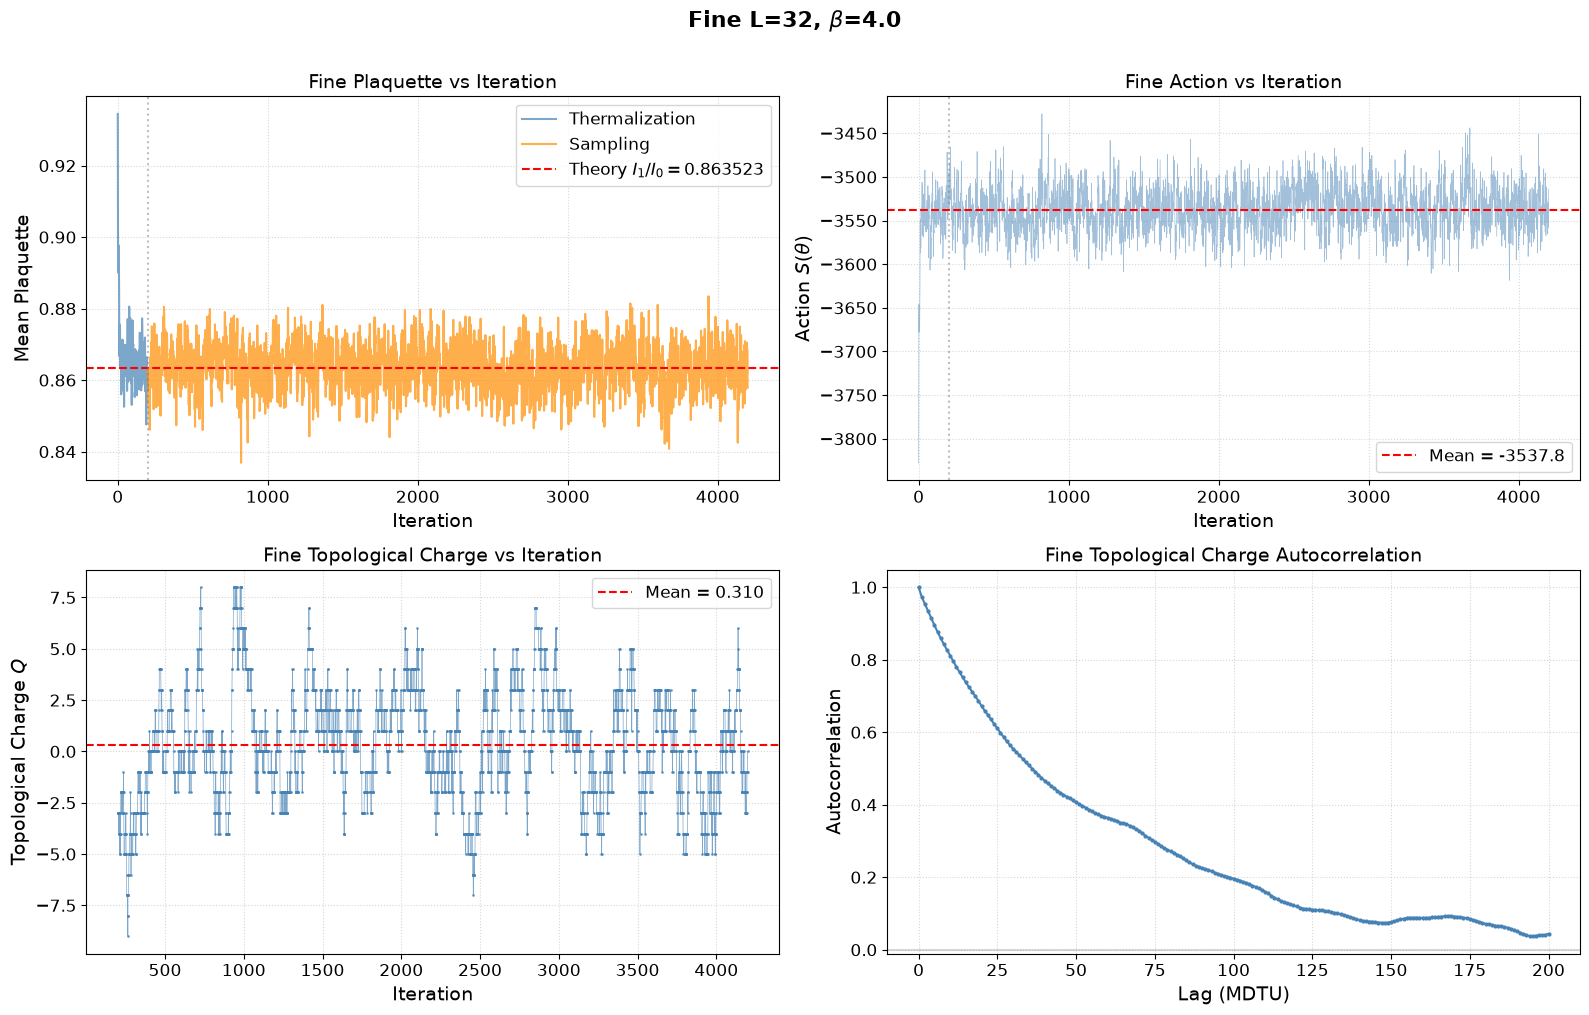

--- Fine Summary (L=32, beta=4.0) ---
Acceptance rate: 0.9888
Mean plaquette (measured): 0.863714
Mean plaquette (theory):   0.863523
Difference:                0.000192
Topological susceptibility (measured): 0.006881
Topological susceptibility (theory):   0.007554


In [3]:
def plot_hmc_diagnostics(diag, beta, L, title_prefix=""):
    """4-panel HMC diagnostics plot."""
    volume = L * L
    burn = diag.burn_in_length
    n_total = len(diag.plaquette_history)
    iters = np.arange(n_total)
    plaq = np.array(diag.plaquette_history)
    action = np.array(diag.hamiltonian_history)
    topo = np.array(diag.topological_charge_history)

    plaq_exact = plaquette_theory(beta)
    chi_exact = topological_susceptibility_theory(beta)

    # n_total // 4 divides by 4 and then rounds down
    max_lag = min(200, n_total // 4)
    autocor = autocorrelation_from_topo(topo[burn:], max_lag, beta, volume)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fs = 14

    ax = axes[0, 0]
    ax.plot(iters[:burn], plaq[:burn], color='steelblue', alpha=0.7, label='Thermalization')
    ax.plot(iters[burn:], plaq[burn:], color='darkorange', alpha=0.7, label='Sampling')
    ax.axhline(plaq_exact, color='red', linestyle='--', linewidth=1.5,
               label=rf'Theory $I_1/I_0 = {plaq_exact:.6f}$')
    ax.axvline(burn, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Iteration', fontsize=fs)
    ax.set_ylabel('Mean Plaquette', fontsize=fs)
    ax.set_title(f'{title_prefix}Plaquette vs Iteration', fontsize=fs)
    ax.legend(fontsize=fs - 2)
    ax.tick_params(labelsize=fs - 2)
    ax.grid(linestyle=':', alpha=0.5)

    ax = axes[0, 1]
    ax.plot(iters, action, color='steelblue', alpha=0.5, linewidth=0.5)
    ax.axhline(np.mean(action[burn:]), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(action[burn:]):.1f}')
    ax.axvline(burn, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Iteration', fontsize=fs)
    ax.set_ylabel(r'Action $S(\theta)$', fontsize=fs)
    ax.set_title(f'{title_prefix}Action vs Iteration', fontsize=fs)
    ax.legend(fontsize=fs - 2)
    ax.tick_params(labelsize=fs - 2)
    ax.grid(linestyle=':', alpha=0.5)

    ax = axes[1, 0]
    ax.plot(iters[burn:], topo[burn:], color='steelblue', alpha=0.7,
            marker='o', markersize=1, linewidth=0.5)
    ax.axhline(np.mean(topo[burn:]), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(topo[burn:]):.3f}')
    ax.set_xlabel('Iteration', fontsize=fs)
    ax.set_ylabel(r'Topological Charge $Q$', fontsize=fs)
    ax.set_title(f'{title_prefix}Topological Charge vs Iteration', fontsize=fs)
    ax.legend(fontsize=fs - 2)
    ax.tick_params(labelsize=fs - 2)
    ax.grid(linestyle=':', alpha=0.5)

    ax = axes[1, 1]
    ax.plot(range(len(autocor)), autocor, color='steelblue', marker='o', markersize=2)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('Lag (MDTU)', fontsize=fs)
    ax.set_ylabel('Autocorrelation', fontsize=fs)
    ax.set_title(f'{title_prefix}Topological Charge Autocorrelation', fontsize=fs)
    ax.tick_params(labelsize=fs - 2)
    ax.grid(linestyle=':', alpha=0.5)

    fig.suptitle(rf'{title_prefix}L={L}, $\beta$={beta}', fontsize=fs + 2, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()

    plaq_measured = np.mean(plaq[burn:])
    topo_arr = np.array(topo[burn:])
    suscept_measured = np.mean(topo_arr**2) / volume
    accept_total = np.mean(diag.acceptance_history)

    print(f"--- {title_prefix}Summary (L={L}, beta={beta}) ---")
    print(f"Acceptance rate: {accept_total:.4f}")
    print(f"Mean plaquette (measured): {plaq_measured:.6f}")
    print(f"Mean plaquette (theory):   {plaq_exact:.6f}")
    print(f"Difference:                {plaq_measured - plaq_exact:.6f}")
    print(f"Topological susceptibility (measured): {suscept_measured:.6f}")
    print(f"Topological susceptibility (theory):   {chi_exact:.6f}")


plot_hmc_diagnostics(fine_diag, FINE_BETA, FINE_L, title_prefix="Fine ")

---
## Section B: Naive MCRG Blocking

### The 2x2 Blocking Map

We block the $32 \times 32$ fine lattice down to a $16 \times 16$ coarse lattice using the **naive 2x2 blocking** scheme:

For a 2x2 block starting at fine site $(2i, 2j)$:
- **Coarse x-link**: $\Theta_x(i,j) = \mathrm{regularize}\big(\theta_x(2i, 2j) + \theta_x(2i{+}1, 2j)\big)$
- **Coarse y-link**: $\Theta_y(i,j) = \mathrm{regularize}\big(\theta_y(2i, 2j) + \theta_y(2i, 2j{+}1)\big)$

This sums two consecutive fine-link phases along the same direction, then wraps the result back to $[-\pi, \pi]$.

### Why This Preserves Gauge Symmetry

In terms of link variables $U_\mu(x) = e^{i\theta_\mu(x)}$, summing the phases is equivalent to multiplying the link variables:
$$e^{i\Theta_x(i,j)} = e^{i\theta_x(2i,2j)} \cdot e^{i\theta_x(2i+1,2j)}$$

Under a gauge transformation $\theta_\mu(x) \to \theta_\mu(x) + \alpha(x) - \alpha(x+\hat\mu)$, the coarse link transforms as:
$$\Theta_x(i,j) \to \Theta_x(i,j) + \alpha(2i, 2j) - \alpha(2i+2, 2j)$$

which is a gauge transformation on the coarse lattice with $A(i,j) = \alpha(2i, 2j)$.

In [4]:
blocker = NaiveBlocker()
blocked_configs = blocker(fine_configs)
print(f"Fine configs shape:    {fine_configs.shape}")
print(f"Blocked configs shape: {blocked_configs.shape}")

Fine configs shape:    torch.Size([1000, 2, 32, 32])
Blocked configs shape: torch.Size([1000, 2, 16, 16])


### Lattice Configuration: Before and After Blocking

To illustrate the 2x2 blocking map concretely, we visualize a small $4 \times 4$ region from a single fine-lattice configuration alongside the corresponding $2 \times 2$ blocked result.

- **Blue arrows**: x-links ($\theta_x$), with angle values along each link
- **Red arrows**: y-links ($\theta_y$), with angle values along each link
- **Yellow boxes**: plaquette angle $\theta_P$ at the center of each elementary square

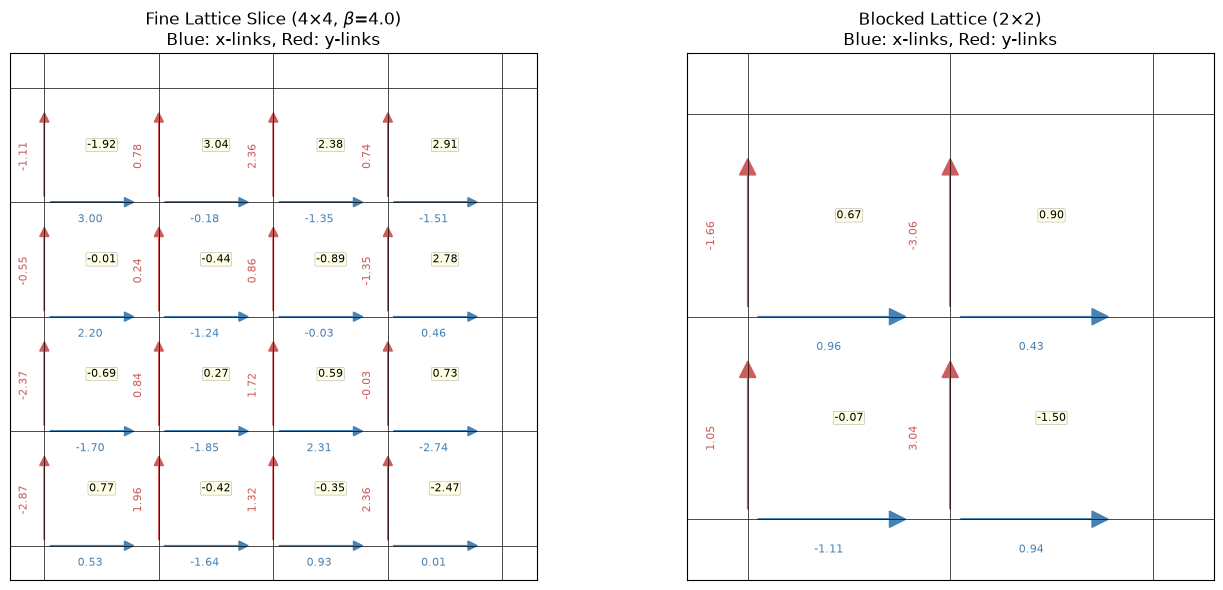

In [5]:
def plot_lattice_config(ax, config, title):
    config_np = config.detach().numpy()
    L = config_np.shape[1]
    thetaP = plaquette_angles(config).detach().numpy()

    for i in range(L + 1):
        ax.axhline(y=i, color='black', linewidth=0.5)
        ax.axvline(x=i, color='black', linewidth=0.5)

    for i in range(L):
        for j in range(L):
            val = f"{config_np[0, i, j]:.2f}"
            ax.arrow(i + 0.05, j, 0.65, 0, head_width=0.08, head_length=0.08,
                     fc='steelblue', ec='steelblue')
            ax.text(i + 0.4, j - 0.15, val, ha='center', va='center',
                    fontsize=8, color='steelblue')

    for i in range(L):
        for j in range(L):
            val = f"{config_np[1, i, j]:.2f}"
            ax.arrow(i, j + 0.05, 0, 0.65, head_width=0.08, head_length=0.08,
                     fc='indianred', ec='indianred')
            ax.text(i - 0.18, j + 0.4, val, ha='center', va='center',
                    fontsize=8, color='indianred', rotation=90)

    for i in range(L):
        for j in range(L):
            plaq_val = f"{thetaP[i, j]:.2f}"
            ax.text(i + 0.5, j + 0.5, plaq_val, ha='center', va='center',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='lightyellow',
                              alpha=0.8, edgecolor='gray', linewidth=0.3))

    ax.set_aspect('equal')
    ax.set_xlim(-0.3, L + 0.3)
    ax.set_ylim(-0.3, L + 0.3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=12)


SLICE = 4
fine_slice = fine_configs[0, :, :SLICE, :SLICE]
blocked_slice = blocked_configs[0, :, :SLICE // 2, :SLICE // 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_lattice_config(ax1, fine_slice,
                    rf'Fine Lattice Slice ({SLICE}×{SLICE}, $\beta$={FINE_BETA})'
                    '\nBlue: x-links, Red: y-links')
plot_lattice_config(ax2, blocked_slice,
                    rf'Blocked Lattice ({SLICE // 2}×{SLICE // 2})'
                    '\nBlue: x-links, Red: y-links')
fig.tight_layout()
plt.show()

### Measurement Distributions: Fine vs Blocked

To quantify how the 2x2 blocking changes observable distributions, we compare per-configuration measurement means between the fine ensemble and the MCRG-blocked coarse ensemble. This uses the same methodology as the blocked-fine vs coarse-HMC comparison in Section D: histograms, empirical CDFs, and KS tests for each observable.

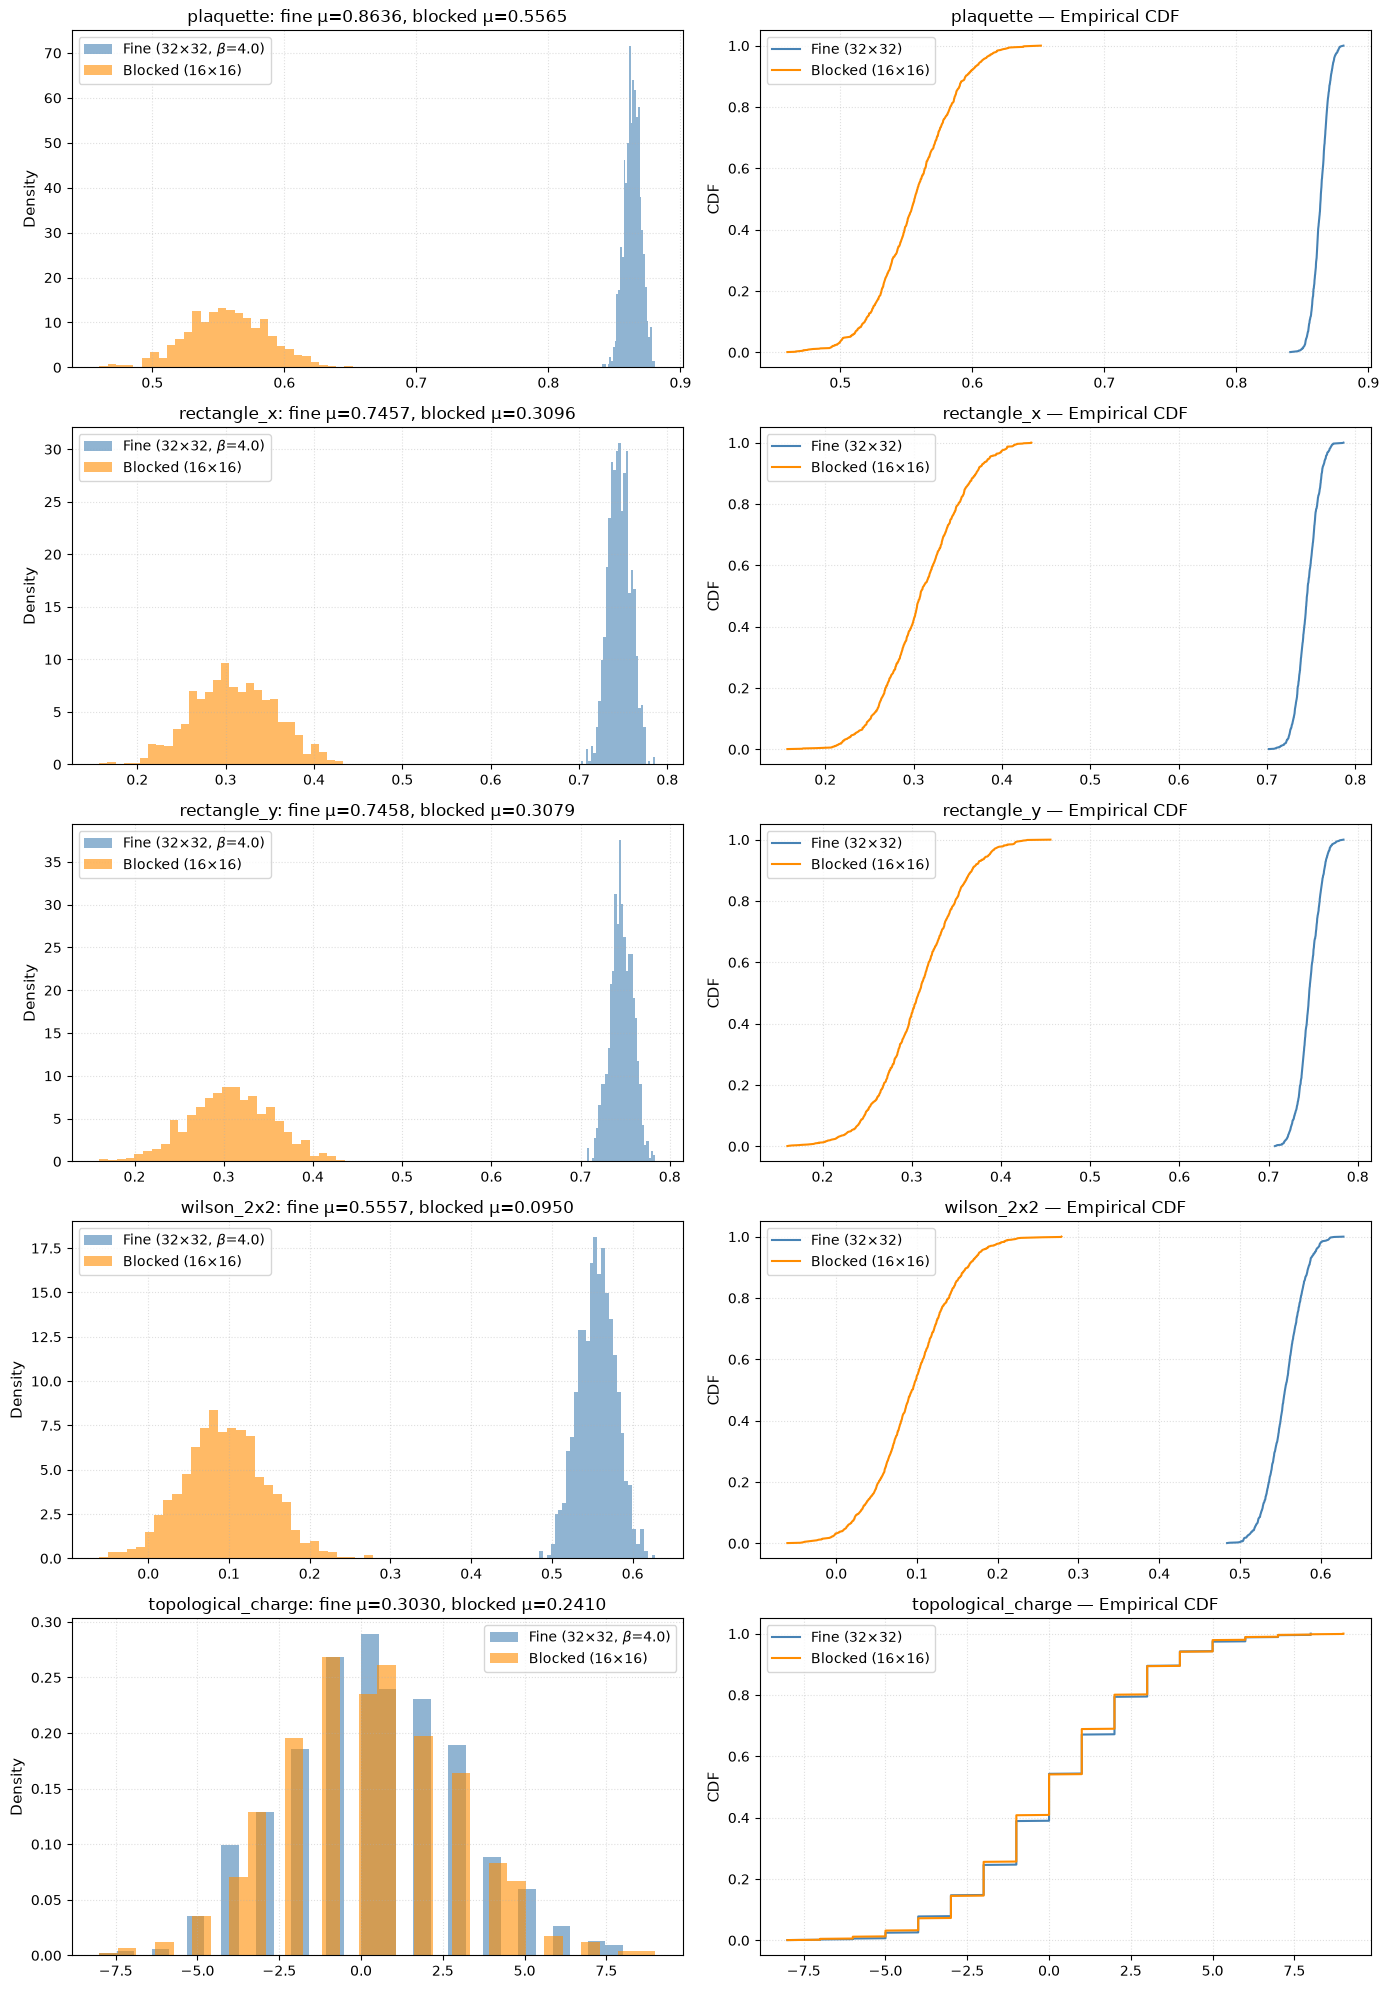

In [6]:
MEAS_NAMES_B = ("plaquette", "rectangle_x", "rectangle_y", "wilson_2x2", "topological_charge")

fine_samples = measurement_samples(fine_configs, MEAS_NAMES_B)
blocked_samples = measurement_samples(blocked_configs, MEAS_NAMES_B)

n_meas = len(MEAS_NAMES_B)
fig, axes = plt.subplots(n_meas, 2, figsize=(14, 4 * n_meas))

for row, mname in enumerate(MEAS_NAMES_B):
    fine_vals = fine_samples[mname].numpy()
    blocked_vals = blocked_samples[mname].numpy()

    ax_hist = axes[row, 0]
    ax_hist.hist(fine_vals, bins=30, density=True, alpha=0.6, color='steelblue',
                 label=rf'Fine ({FINE_L}×{FINE_L}, $\beta$={FINE_BETA})')
    ax_hist.hist(blocked_vals, bins=30, density=True, alpha=0.6, color='darkorange',
                 label=rf'Blocked ({COARSE_L}×{COARSE_L})')
    fine_mean = fine_vals.mean()
    blocked_mean = blocked_vals.mean()
    ax_hist.set_title(
        f'{mname}: fine μ={fine_mean:.4f}, blocked μ={blocked_mean:.4f}',
        fontsize=12)
    ax_hist.legend(fontsize=10)
    ax_hist.set_ylabel('Density', fontsize=11)
    ax_hist.grid(linestyle=':', alpha=0.4)

    ax_cdf = axes[row, 1]
    fine_sorted = np.sort(fine_vals)
    blocked_sorted = np.sort(blocked_vals)
    fine_cdf = np.arange(1, len(fine_sorted) + 1) / len(fine_sorted)
    blocked_cdf = np.arange(1, len(blocked_sorted) + 1) / len(blocked_sorted)
    ax_cdf.plot(fine_sorted, fine_cdf, color='steelblue', linewidth=1.5,
                label=rf'Fine ({FINE_L}×{FINE_L})')
    ax_cdf.plot(blocked_sorted, blocked_cdf, color='darkorange', linewidth=1.5,
                label=rf'Blocked ({COARSE_L}×{COARSE_L})')
    ax_cdf.set_title(f'{mname} — Empirical CDF', fontsize=12)
    ax_cdf.legend(fontsize=10)
    ax_cdf.set_ylabel('CDF', fontsize=11)
    ax_cdf.grid(linestyle=':', alpha=0.4)

fig.tight_layout()
plt.show()

# Why is there such a significant difference between the observables, yet good overlap for the topological charge?

---
## Section C: Independent Coarse HMC

We now generate an independent ensemble on the coarse lattice ($L=16$) using the Wilson action at $\beta_c = \beta_f / 4 = 1.0$.

**If the naive blocking + tree-level $\beta_c$ hypothesis is correct**, the distributions of observables measured on the blocked-fine ensemble and the coarse-HMC ensemble should agree.

In [7]:
coarse_cache = CACHE_DIR / f"coarse_L{COARSE_L}_beta{COARSE_BETA}_n{N_CONFIGS}.pkl"

if coarse_cache.exists():
    print(f"Loading coarse ensemble from cache: {coarse_cache}")
    with open(coarse_cache, "rb") as f:
        cache = pickle.load(f)
    coarse_configs = cache["configs"]
    coarse_acc = cache["acceptance_rate"]
    coarse_diag = cache["diagnostics"]
else:
    coarse_action = LocalWilsonLoopAction.wilson(COARSE_BETA)
    coarse_sampler = HMCU1Sampler(
        lattice_size=COARSE_L,
        action=coarse_action,
        n_steps=HMC_STEPS,
        step_size=HMC_STEP_SIZE,
    )

    print(f"Generating {N_CONFIGS} coarse configs on {COARSE_L}x{COARSE_L} lattice at beta={COARSE_BETA}...")

    coarse_configs, coarse_acc, _, coarse_diag = coarse_sampler.sample_with_diagnostics(
        n_samples=N_CONFIGS,
        burn_in=BURN_IN,
        thin=THIN,
    )

    with open(coarse_cache, "wb") as f:
        pickle.dump({"configs": coarse_configs, "acceptance_rate": coarse_acc, "diagnostics": coarse_diag}, f)
    print(f"Saved to cache: {coarse_cache}")

print(f"Coarse configs shape: {coarse_configs.shape}")
print(f"Acceptance rate: {coarse_acc:.4f}")

Loading coarse ensemble from cache: ..\artifacts\cache\coarse_L16_beta1.0_n1000.pkl
Coarse configs shape: torch.Size([1000, 2, 16, 16])
Acceptance rate: 0.9967


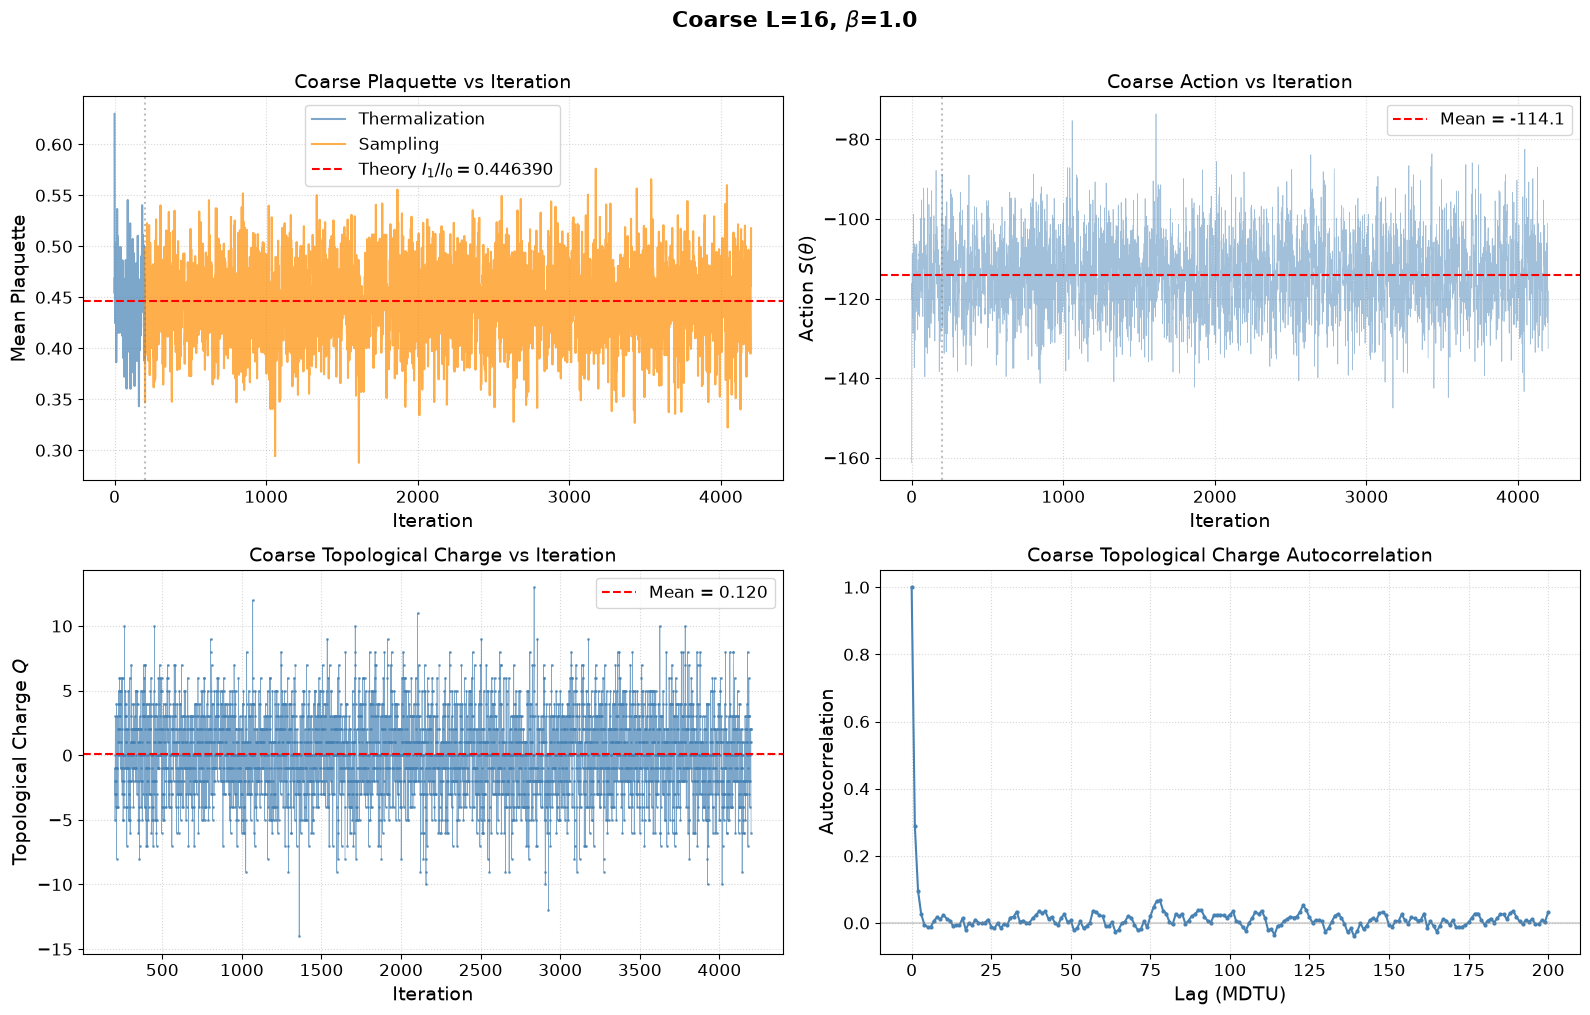

--- Coarse Summary (L=16, beta=1.0) ---
Acceptance rate: 0.9967
Mean plaquette (measured): 0.445775
Mean plaquette (theory):   0.446390
Difference:                -0.000615
Topological susceptibility (measured): 0.040494
Topological susceptibility (theory):   0.040636


In [8]:
plot_hmc_diagnostics(coarse_diag, COARSE_BETA, COARSE_L, title_prefix="Coarse ")

---
## Section D: Blocked-Fine vs Coarse-HMC Comparison

This is the key section. We compare the distributions of physical observables measured on:
1. **Blocked-fine ensemble** -- fine configs blocked to the coarse lattice via naive 2x2 blocking
2. **Coarse-HMC ensemble** -- independently generated coarse configs from the Wilson action at $\beta_c = 1.0$

For each observable, we show:
- Overlay histograms
- Empirical CDF comparison
- Two-sample Kolmogorov-Smirnov (KS) test

### Observables
| Observable | Description |
|---|---|
| `plaquette` | $\langle \cos(\theta_P) \rangle$ per configuration |
| `rectangle_x` | $\langle \cos(\theta_{2 \times 1}) \rangle$ per configuration |
| `rectangle_y` | $\langle \cos(\theta_{1 \times 2}) \rangle$ per configuration |
| `wilson_2x2` | $\langle \cos(\theta_{2 \times 2}) \rangle$ per configuration |
| `topological_charge` | $Q = \mathrm{round}\big(\frac{1}{2\pi}\sum_P \theta_P\big)$ per configuration |

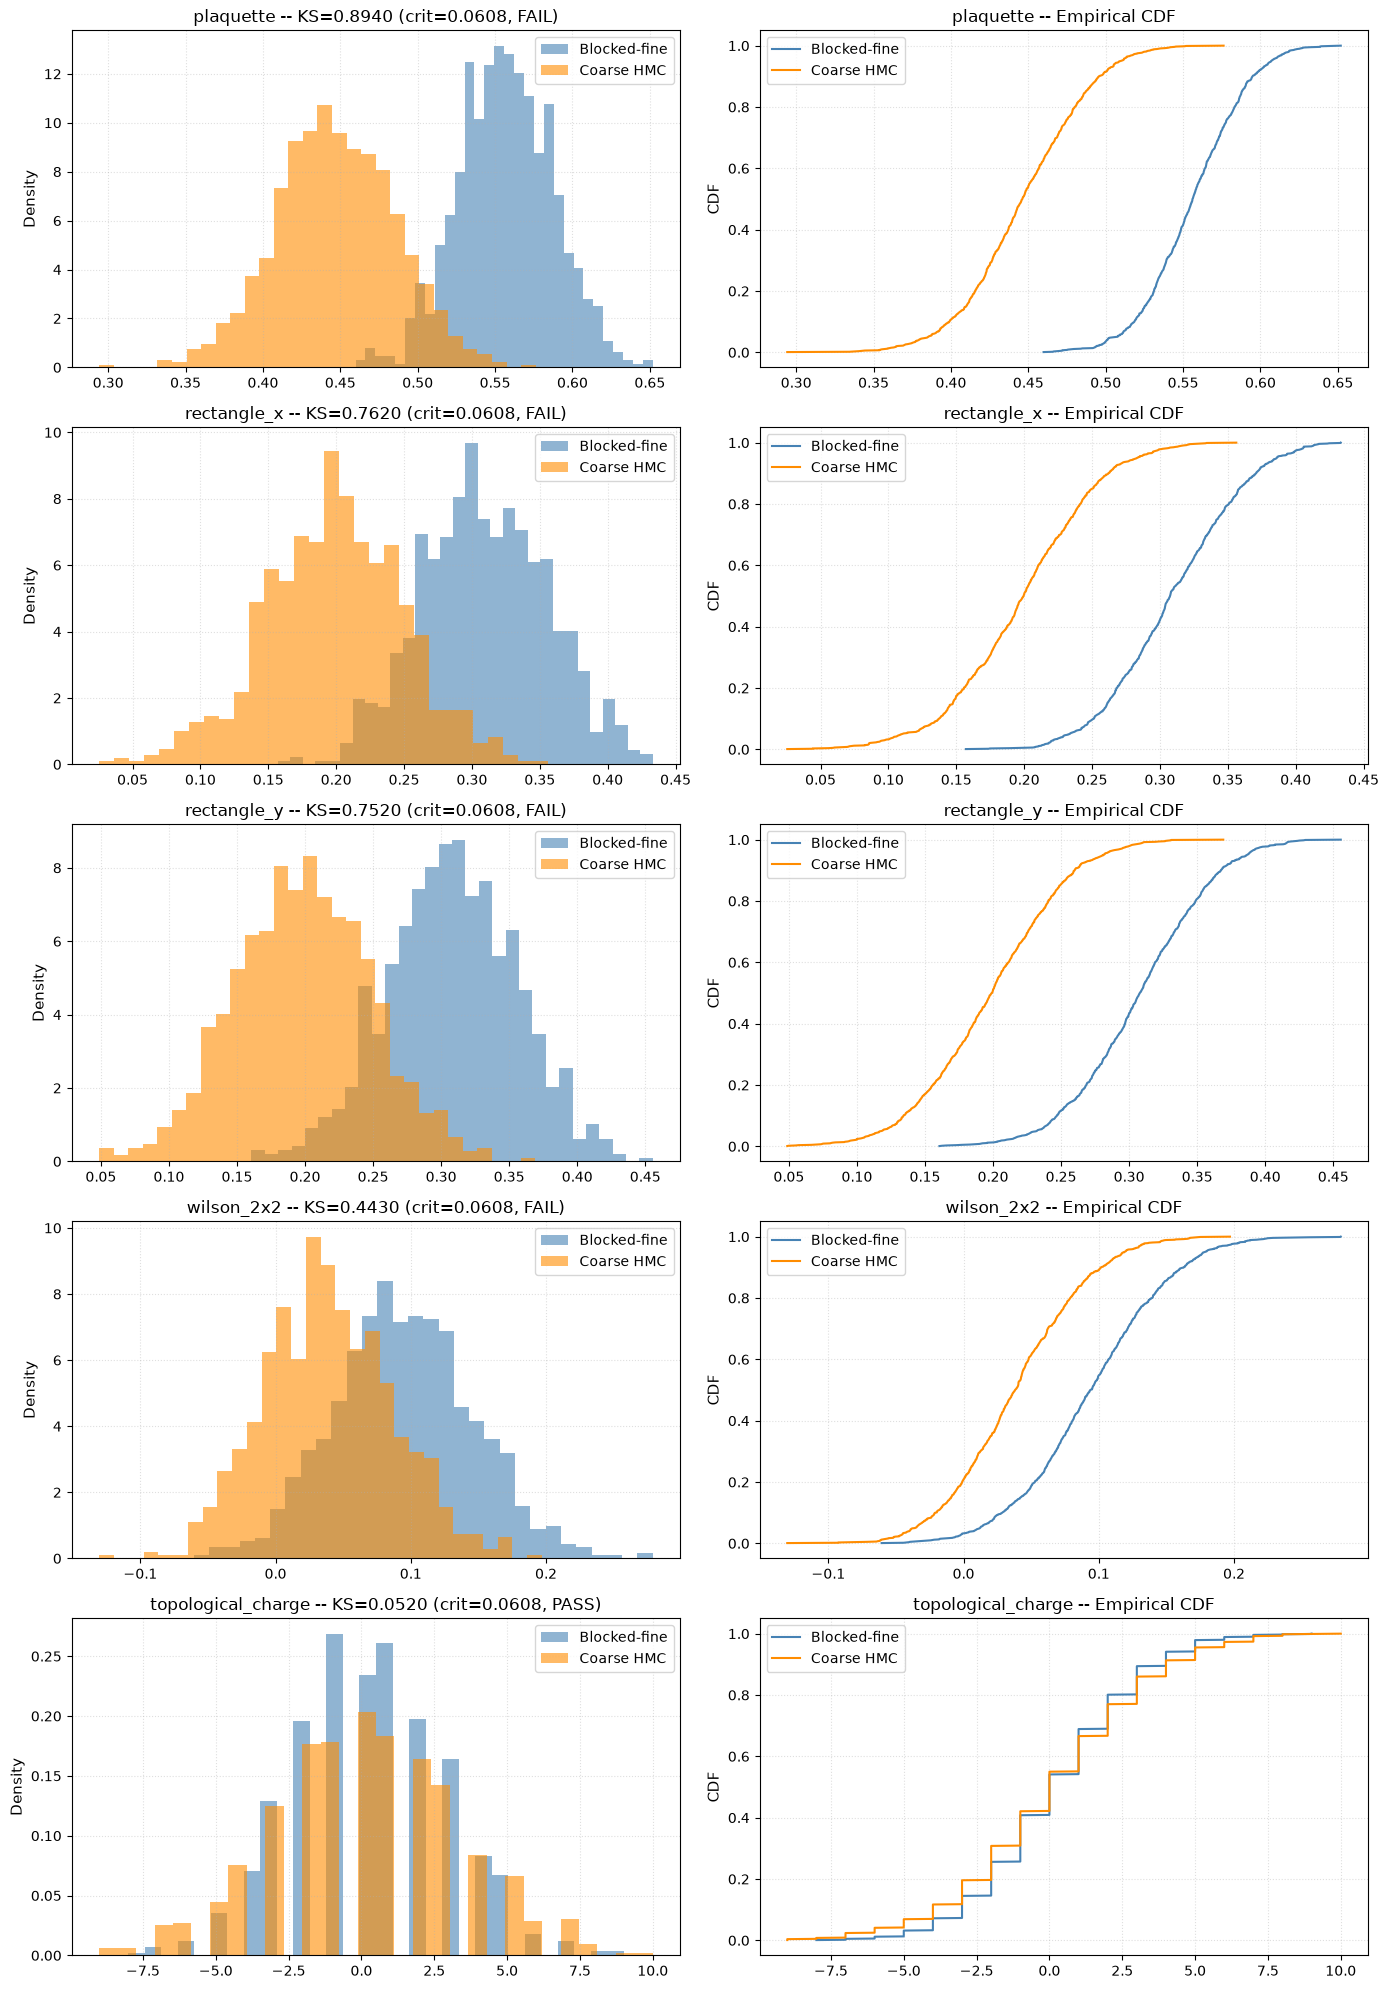

In [9]:
MEASUREMENT_NAMES = ("plaquette", "rectangle_x", "rectangle_y", "wilson_2x2", "topological_charge")

diagnostics_list, merged_samples = analyze_distribution_consistency(
    blocked_configs,
    coarse_configs,
    measurement_names=MEASUREMENT_NAMES,
)

n_meas = len(MEASUREMENT_NAMES)
fig, axes = plt.subplots(n_meas, 2, figsize=(14, 4 * n_meas))

for row, (diag_item, mname) in enumerate(zip(diagnostics_list, MEASUREMENT_NAMES)):
    blocked_vals = merged_samples[f"blocked_{mname}"].numpy()
    coarse_vals = merged_samples[f"coarse_{mname}"].numpy()

    ax_hist = axes[row, 0]
    ax_hist.hist(blocked_vals, bins=30, density=True, alpha=0.6, color='steelblue', label='Blocked-fine')
    ax_hist.hist(coarse_vals, bins=30, density=True, alpha=0.6, color='darkorange', label='Coarse HMC')
    verdict = 'PASS' if diag_item.consistent else 'FAIL'
    ax_hist.set_title(f'{mname} -- KS={diag_item.ks_statistic:.4f} (crit={diag_item.ks_critical_value:.4f}, {verdict})',
                      fontsize=12)
    ax_hist.legend(fontsize=10)
    ax_hist.set_ylabel('Density', fontsize=11)
    ax_hist.grid(linestyle=':', alpha=0.4)

    ax_cdf = axes[row, 1]
    blocked_sorted = np.sort(blocked_vals)
    coarse_sorted = np.sort(coarse_vals)
    blocked_cdf = np.arange(1, len(blocked_sorted) + 1) / len(blocked_sorted)
    coarse_cdf = np.arange(1, len(coarse_sorted) + 1) / len(coarse_sorted)
    ax_cdf.plot(blocked_sorted, blocked_cdf, color='steelblue', linewidth=1.5, label='Blocked-fine')
    ax_cdf.plot(coarse_sorted, coarse_cdf, color='darkorange', linewidth=1.5, label='Coarse HMC')
    ax_cdf.set_title(f'{mname} -- Empirical CDF', fontsize=12)
    ax_cdf.legend(fontsize=10)
    ax_cdf.set_ylabel('CDF', fontsize=11)
    ax_cdf.grid(linestyle=':', alpha=0.4)

fig.tight_layout()
plt.show()

### Summary Table

In [10]:
header = "| Measurement | Blocked Mean | Coarse Mean | Blocked Std | Coarse Std | KS Stat | KS Critical | Verdict |"
sep    = "|---|---:|---:|---:|---:|---:|---:|---|"
rows = [header, sep]

for d in diagnostics_list:
    verdict = "PASS" if d.consistent else "**FAIL**"
    rows.append(
        f"| {d.measurement} | {d.blocked_mean:.6f} | {d.coarse_mean:.6f} | "
        f"{d.blocked_std:.6f} | {d.coarse_std:.6f} | {d.ks_statistic:.4f} | "
        f"{d.ks_critical_value:.4f} | {verdict} |"
    )

display(Markdown("\n".join(rows)))

| Measurement | Blocked Mean | Coarse Mean | Blocked Std | Coarse Std | KS Stat | KS Critical | Verdict |
|---|---:|---:|---:|---:|---:|---:|---|
| plaquette | 0.556499 | 0.447162 | 0.030604 | 0.038275 | 0.8940 | 0.0608 | **FAIL** |
| rectangle_x | 0.309607 | 0.198712 | 0.046217 | 0.050733 | 0.7620 | 0.0608 | **FAIL** |
| rectangle_y | 0.307946 | 0.198471 | 0.047043 | 0.049506 | 0.7520 | 0.0608 | **FAIL** |
| wilson_2x2 | 0.095005 | 0.039205 | 0.051436 | 0.047225 | 0.4430 | 0.0608 | **FAIL** |
| topological_charge | 0.241000 | 0.136000 | 2.641007 | 3.175138 | 0.0520 | 0.0608 | PASS |

---
## Section E: Summary and Next Steps

### What We Did

1. Generated 1000 fine-lattice configurations ($32 \times 32$, $\beta_f = 4.0$) using HMC with Omelyan integrator.
2. Applied naive 2x2 blocking (sum two consecutive link phases, regularize) to obtain 1000 blocked-coarse configurations on $16 \times 16$.
3. Generated 1000 independent coarse configurations ($16 \times 16$, $\beta_c = 1.0$) via HMC.
4. Compared the two coarse ensembles at the distribution level using histograms, CDFs, and KS tests for five observables.

### Interpretation

The naive blocking with tree-level $\beta_c = \beta_f / 4$ provides a first approximation. Discrepancies between the blocked-fine and coarse-HMC distributions reveal where the naive approach breaks down -- this motivates the next phase.

### Next Steps

1. **Learned Blocking**: Replace the naive blocker with a learnable gauge-covariant path-weight blocker that can optimize path combinations.
2. **Generalized Coarse Action**: Extend the coarse action beyond pure Wilson by adding rectangle and larger loop terms.
3. **Joint Training**: Simultaneously optimize the blocking map and coarse action coefficients using distribution-matching losses (MMD + contrastive).
4. **Scaling**: Test at larger lattice sizes and multiple $\beta_f$ values to validate universality of the learned map.